In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import os
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load .npz file from Drive
data = np.load("/content/drive/MyDrive/lulc_patches_labels.npz")
X = data['patches']  # Shape: (N, H, W, C) or (N, C, H, W)
y = data['labels']   # Shape: (N,)


In [8]:
np.unique(y)

array([0, 1], dtype=uint8)

In [2]:
class PatchDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = int(self.y[idx])

        # Convert to float and normalize
        image = image.astype(np.float32) / 255.0
        #image = np.transpose(image, (2, 0, 1))  # HWC → CHW
        #image = torch.tensor(image, dtype=torch.float)

        if self.transform:
            image = self.transform(image)

        return image, label

In [3]:
# Augmentation and preprocessing
input_size = 456  # for EfficientNet-B0
# transform = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.Resize((input_size, input_size)),
#     transforms.ToTensor(),
# ])
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

# Create dataset and dataloaders
dataset = PatchDataset(X, y, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=2,shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)
def get_default_device():
  if torch.cuda.is_available():
    return torch.device('cuda')
  else:
    return torch.device('cpu')

def to_device(data,device):
  if isinstance(data,(list,tuple)):
    return [to_device(x,device) for x in data]
  else:
    return data.to(device,non_blocking=True)

class DeviceDataloader():
  def __init__(self,device,dl):
    self.dl=dl
    self.device=device

  def __iter__(self):
    for batch in self.dl:
      yield to_device(batch,self.device)

  def __len__(self):
    return len(self.dl)

device=get_default_device()
train_dl=DeviceDataloader(device,train_loader)
test_dl=DeviceDataloader(device,val_loader)
device

device(type='cuda')

In [4]:
model = models.efficientnet_b5(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B5_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B5_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
opt=torch.optim.Adam(model.parameters(),lr=1e-3)
#from torch.optim.lr_scheduler import OneCycleLR
criterion = nn.CrossEntropyLoss()
#scheduler = OneCycleLR(opt, max_lr=1e-3, epochs=50, steps_per_epoch=len(train_dl))
train_epoch_losses=[]
test_epoch_losses=[]
best_loss=1
for epoch in range(100):  # Set the number of epochs
    model.train()
    train_epoch_loss = 0
    test_epoch_loss=0
    for images, label in train_dl:
        # Forward pass
        outputs = model(images)
        loss=criterion(outputs, label)
        train_epoch_loss += loss.item()

        # Backward pass
        opt.zero_grad()
        loss.backward()
        opt.step()
        #scheduler.step()
    train_epoch_losses.append(train_epoch_loss/len(train_dl))
    print(f"Epoch {epoch+1}, Train Loss: {train_epoch_loss/len(train_dl)}")

    for images, label in test_dl:
        model.eval()
        with torch.no_grad():
            outputs = model(images)
            loss = criterion(outputs, label)
            test_epoch_loss += loss.item()
    test_epoch_losses.append(test_epoch_loss/len(test_dl))
    print(f"Test Loss: {test_epoch_loss/len(test_dl)}")
    if test_epoch_loss/len(test_dl)<best_loss:
      best_loss=test_epoch_loss/len(test_dl)
      torch.save(model.state_dict(),f"/content/drive/MyDrive/best6.pt")

OutOfMemoryError: CUDA out of memory. Tried to allocate 40.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 34.12 MiB is free. Process 343550 has 14.71 GiB memory in use. Of the allocated memory 14.44 GiB is allocated by PyTorch, and 152.41 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

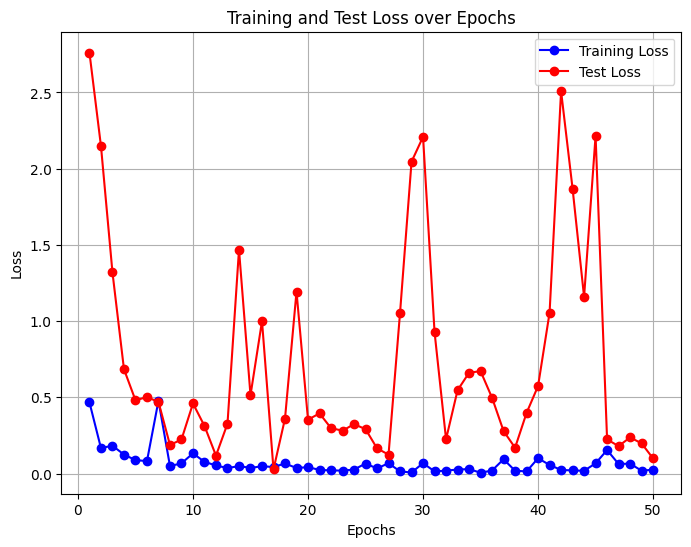

In [31]:
import matplotlib.pyplot as plt

# Assuming you have these lists:
# train_epoch_loss = [train_loss_epoch1, train_loss_epoch2, ...]
# test_epoch_loss = [test_loss_epoch1, test_loss_epoch2, ...]

epochs = range(1, 51)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_epoch_losses, 'b-o', label='Training Loss')
plt.plot(epochs, test_epoch_losses, 'r-o', label='Test Loss')
plt.title('Training and Test Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
y_true = []
y_pred = []
model.load_state_dict(torch.load("/content/drive/MyDrive/best.pt"))
model.eval()
for images, labels in test_dl:
    # images are already on the correct device due to DeviceDataloader
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Move labels to CPU before converting to numpy
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1", "Class 2"],labels=[0,1,2]))

<ipython-input-37-5f912c3b7b82>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/best.pt"))


              precision    recall  f1-score   support

     Class 0       0.94      1.00      0.97        31
     Class 1       1.00      0.90      0.95        21
     Class 2       0.00      0.00      0.00         0

    accuracy                           0.96        52
   macro avg       0.65      0.63      0.64        52
weighted avg       0.96      0.96      0.96        52



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

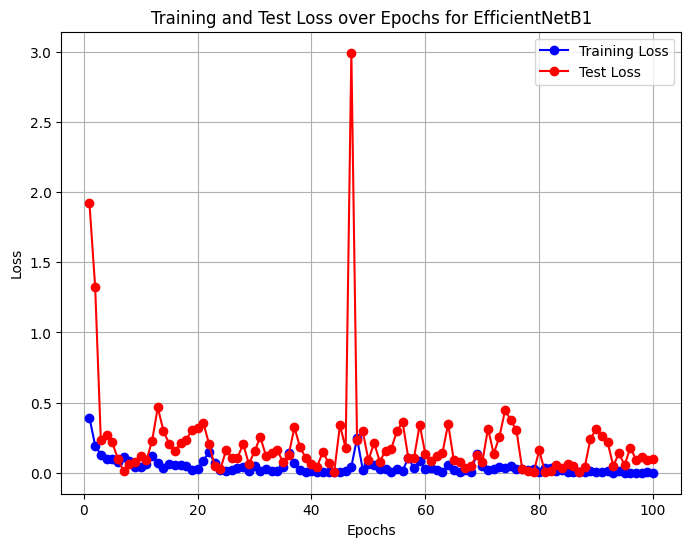

In [6]:
import matplotlib.pyplot as plt

# Assuming you have these lists:
# train_epoch_loss = [train_loss_epoch1, train_loss_epoch2, ...]
# test_epoch_loss = [test_loss_epoch1, test_loss_epoch2, ...]

epochs = range(1, 101)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_epoch_losses, 'b-o', label='Training Loss')
plt.plot(epochs, test_epoch_losses, 'r-o', label='Test Loss')
plt.title('Training and Test Loss over Epochs for EfficientNetB1')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
y_true = []
y_pred = []
model.load_state_dict(torch.load("/content/drive/MyDrive/best1.pt"))
model.eval()
for images, labels in test_dl:
    # images are already on the correct device due to DeviceDataloader
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Move labels to CPU before converting to numpy
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1", "Class 2"],labels=[0,1,2]))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        39
     Class 1       1.00      1.00      1.00        13
     Class 2       0.00      0.00      0.00         0

    accuracy                           1.00        52
   macro avg       0.67      0.67      0.67        52
weighted avg       1.00      1.00      1.00        52



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

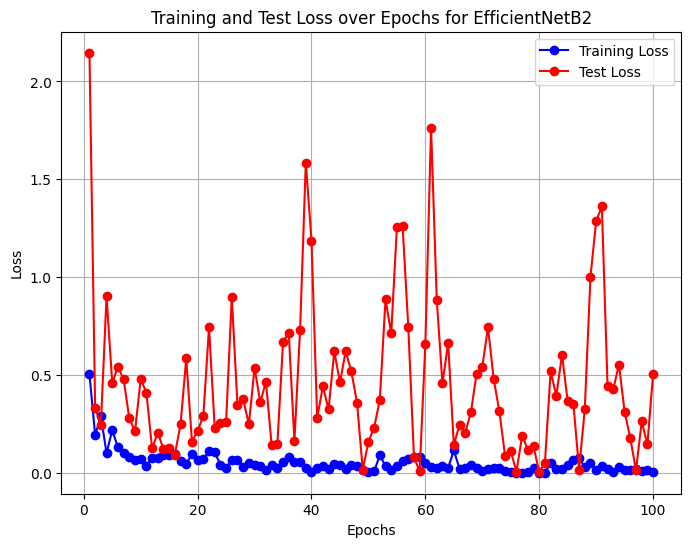

In [12]:
import matplotlib.pyplot as plt

# Assuming you have these lists:
# train_epoch_loss = [train_loss_epoch1, train_loss_epoch2, ...]
# test_epoch_loss = [test_loss_epoch1, test_loss_epoch2, ...]

epochs = range(1, 101)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_epoch_losses, 'b-o', label='Training Loss')
plt.plot(epochs, test_epoch_losses, 'r-o', label='Test Loss')
plt.title('Training and Test Loss over Epochs for EfficientNetB2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
y_true = []
y_pred = []
model.load_state_dict(torch.load("/content/drive/MyDrive/best2.pt"))
model.eval()
for images, labels in test_dl:
    # images are already on the correct device due to DeviceDataloader
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Move labels to CPU before converting to numpy
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"]))

              precision    recall  f1-score   support

     Class 0       0.96      1.00      0.98        27
     Class 1       1.00      0.96      0.98        25

    accuracy                           0.98        52
   macro avg       0.98      0.98      0.98        52
weighted avg       0.98      0.98      0.98        52



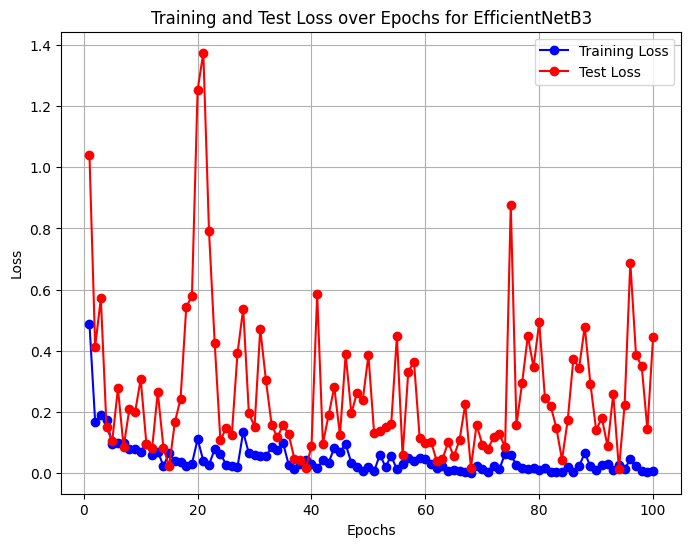

In [17]:
import matplotlib.pyplot as plt

# Assuming you have these lists:
# train_epoch_loss = [train_loss_epoch1, train_loss_epoch2, ...]
# test_epoch_loss = [test_loss_epoch1, test_loss_epoch2, ...]

epochs = range(1, 101)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_epoch_losses, 'b-o', label='Training Loss')
plt.plot(epochs, test_epoch_losses, 'r-o', label='Test Loss')
plt.title('Training and Test Loss over Epochs for EfficientNetB3')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
y_true = []
y_pred = []
model.load_state_dict(torch.load("/content/drive/MyDrive/best3.pt"))
model.eval()
for images, labels in test_dl:
    # images are already on the correct device due to DeviceDataloader
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Move labels to CPU before converting to numpy
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"]))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        35
     Class 1       1.00      1.00      1.00        17

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52



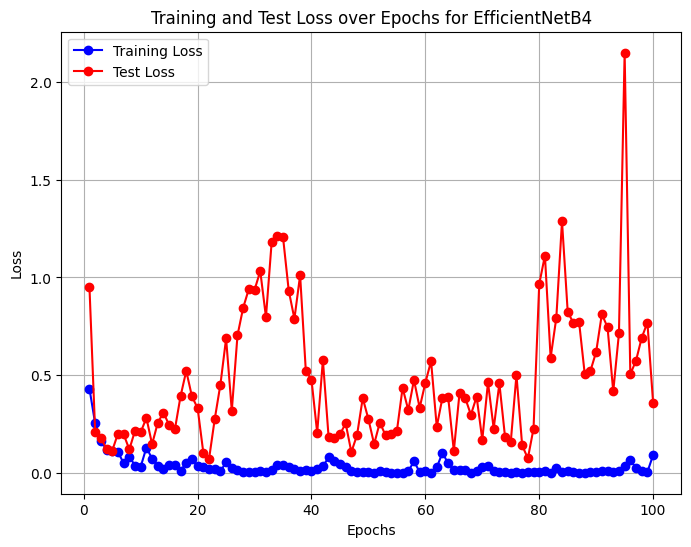

In [9]:
import matplotlib.pyplot as plt

# Assuming you have these lists:
# train_epoch_loss = [train_loss_epoch1, train_loss_epoch2, ...]
# test_epoch_loss = [test_loss_epoch1, test_loss_epoch2, ...]

epochs = range(1, 101)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_epoch_losses, 'b-o', label='Training Loss')
plt.plot(epochs, test_epoch_losses, 'r-o', label='Test Loss')
plt.title('Training and Test Loss over Epochs for EfficientNetB4')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
y_true = []
y_pred = []
model.load_state_dict(torch.load("/content/drive/MyDrive/best4.pt"))
model.eval()
for images, labels in test_dl:
    # images are already on the correct device due to DeviceDataloader
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Move labels to CPU before converting to numpy
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"]))

RuntimeError: Error(s) in loading state_dict for EfficientNet:
	Missing key(s) in state_dict: "features.1.2.block.0.0.weight", "features.1.2.block.0.1.weight", "features.1.2.block.0.1.bias", "features.1.2.block.0.1.running_mean", "features.1.2.block.0.1.running_var", "features.1.2.block.1.fc1.weight", "features.1.2.block.1.fc1.bias", "features.1.2.block.1.fc2.weight", "features.1.2.block.1.fc2.bias", "features.1.2.block.2.0.weight", "features.1.2.block.2.1.weight", "features.1.2.block.2.1.bias", "features.1.2.block.2.1.running_mean", "features.1.2.block.2.1.running_var", "features.2.4.block.0.0.weight", "features.2.4.block.0.1.weight", "features.2.4.block.0.1.bias", "features.2.4.block.0.1.running_mean", "features.2.4.block.0.1.running_var", "features.2.4.block.1.0.weight", "features.2.4.block.1.1.weight", "features.2.4.block.1.1.bias", "features.2.4.block.1.1.running_mean", "features.2.4.block.1.1.running_var", "features.2.4.block.2.fc1.weight", "features.2.4.block.2.fc1.bias", "featu

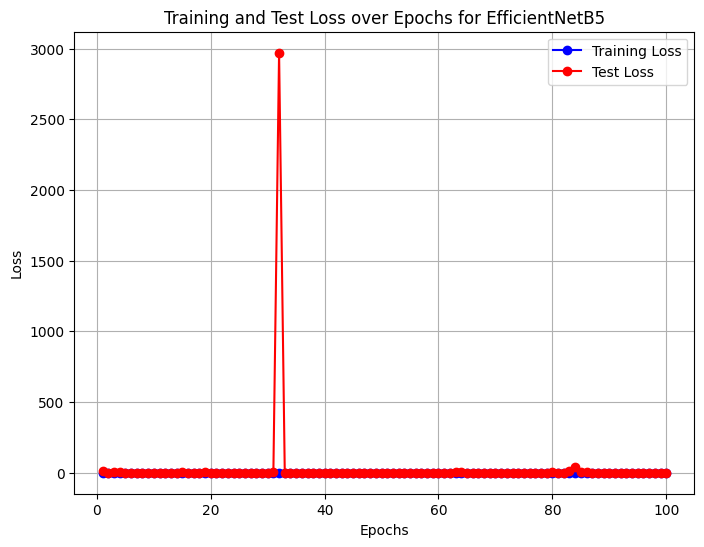

In [6]:
import matplotlib.pyplot as plt

# Assuming you have these lists:
# train_epoch_loss = [train_loss_epoch1, train_loss_epoch2, ...]
# test_epoch_loss = [test_loss_epoch1, test_loss_epoch2, ...]

epochs = range(1, 101)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_epoch_losses, 'b-o', label='Training Loss')
plt.plot(epochs, test_epoch_losses, 'r-o', label='Test Loss')
plt.title('Training and Test Loss over Epochs for EfficientNetB5')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
y_true = []
y_pred = []
model.load_state_dict(torch.load("/content/drive/MyDrive/best5.pt"))
model.eval()
for images, labels in test_dl:
    # images are already on the correct device due to DeviceDataloader
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    # Move labels to CPU before converting to numpy
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"]))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        36
     Class 1       1.00      1.00      1.00        16

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52

